В этом файле улучшиаем модель деревьев решений, которая оказалась наиболее точной при сравнении с другими моделями

Сначала аналогчно файлу test_models подготавливаем препроцессор с данными

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT=Path.cwd().parent
data_path=PROJECT_ROOT / 'data' / 'cars.csv'
artifacts_path=PROJECT_ROOT / 'artifacts'
configs_path=PROJECT_ROOT / 'configs'

RANDOM_STATE = 42

# Я ничего не придумал лучше, чем скопировать обработку сырых данных из файла с EDA
def prepare_raw_data(df):
    
    df=df.drop_duplicates()
    
    df=df.drop(['ID'],axis=1)
    
    df['Price']=df['Price']*73
    
    df['Manufacturer']=df['Manufacturer'].str.lower()
    
    manufacturer_counts = df['Manufacturer'].value_counts()
    rare_manufacturers = manufacturer_counts[manufacturer_counts < 15].index
    df['Manufacturer'] = df['Manufacturer'].replace(rare_manufacturers, 'other')

    df['Model']=df['Model'].str.lower()
    model_counts = df['Model'].value_counts()
    rare_models = model_counts[model_counts < 10].index
    df['Model'] = df['Model'].replace(rare_models, 'other')
    
    df.loc[df['Fuel type'] == 'Plug-in Hybrid', 'Fuel type'] = 'hybrid'
    df.loc[(df['Fuel type'] == 'CNG') | (df['Fuel type'] == 'LPG'), 'Fuel type'] = 'gas'
    df['Fuel type']=df['Fuel type'].str.lower()

    df['Engine volume']=df['Engine volume'].str.replace(" Turbo","")
    df['Engine volume']=df['Engine volume'].astype(float)

    df['Mileage'] = df['Mileage'].str.replace(' km', '').astype(int)

    df['Drive wheels']=df['Drive wheels'].str.lower()

    df.loc[df['Doors'] == '04-May', 'Doors'] = '4'
    df.loc[df['Doors'] == '02-Mar', 'Doors'] = '2'

    df.loc[df['Wheel'] == 'Left wheel', 'Wheel'] = 'left'
    df.loc[df['Wheel'] == 'Right-hand drive', 'Wheel'] = 'right'

    df['Color']=df['Color'].str.lower()

    df = df[(df['Price'] > 50000) & (df['Price'] < df['Price'].quantile(0.98))]
    df = df[(df['Prod. year'] >= 1970) & (df['Prod. year'] <= 2026)]
    df = df[df['Mileage'] >= 0]
    df = df[df['Engine volume'] > 0 & (df['Engine volume'] < df['Engine volume'].quantile(0.98))]
    df = df[(df['Cylinders'] > 0) & (df['Cylinders'] < 16)]

    df=df[df['Mileage']<1000000]

    return df

df = pd.read_csv(data_path)
df = prepare_raw_data(df)

from sklearn.model_selection import train_test_split

num_features = ['Prod. year','Engine volume','Mileage','Cylinders','Airbags']
cat_features = ['Manufacturer','Model','Category','Leather interior','Fuel type','Gear box type','Drive wheels','Doors','Wheel','Color']

X = df[num_features + cat_features]
y = np.log(df['Price'])      # логарифм цены – целевая переменная

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

preprocessor.fit(X_train)

# Преобразуем данные
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [2]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

# KFold для кросс-валидации
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []           # список метрик для каждой модели
best_models = {}       # обученная модель
search_summaries = {}  # best_params, best_cv_score

def compute_metrics(y_true, y_pred):
    """Расчёт метрик"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {
        "mae": float(mae),
        "mse": float(mse),
        "rmse": float(rmse)
    }

def print_metrics(y_true, y_pred, title=None):
    """Вывод метрик"""
    if title:
        print(f"\n{title}")
        print("=" * len(title))
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"MAE  = {mae:.4f}")
    print(f"MSE  = {mse:.4f}")
    print(f"RMSE = {rmse:.4f}")

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    """Оценка модели на тестовых данных"""
    y_pred = model.predict(X_test)
    metrics = compute_metrics(y_test, y_pred)
    metrics["model"] = label
    return metrics

def save_json(obj, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def run_search(label, estimator, param_grid, X_train, y_train, X_test, y_test, scoring="neg_mean_squared_error"):
    """Поиск гиперпараметров с GridSearchCV"""
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        verbose=1
    )
    search.fit(X_train, y_train)
    
    best = search.best_estimator_
    best_models[label] = best
    search_summaries[label] = {
        "best_params": search.best_params_,
        "best_cv_score": float(search.best_score_),
        "scoring": scoring
    }
    results.append(evaluate_on_test(best, X_test, y_test, label))
    return search

Базовая модель с исходными лучшими параметрами

In [3]:
from sklearn.ensemble import RandomForestRegressor

initial_params = {
    "max_depth": None,
    "min_samples_leaf": 1,
    "min_samples_split": 2,
    "n_estimators": 200
}

rf_initial = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **initial_params)
rf_initial.fit(X_train_processed, y_train)


y_pred_initial = rf_initial.predict(X_test_processed)
metrics = compute_metrics(y_test, y_pred_initial)
metrics["model"] = "RandomForest_best_old"
results.append(metrics)
print_metrics(y_test, y_pred_initial, title="Initial RandomForest (best_params)")


Initial RandomForest (best_params)
MAE  = 0.2658
MSE  = 0.2128
RMSE = 0.4613


Попробуем перебрать параметры вокруг текущих лучших значений

In [4]:
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [20, 25, None],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", 0.5, 0.7]
}

rf_tune = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
search = run_search("RandomForest_Tuned", rf_tune, param_grid,
                    X_train_processed, y_train, X_test_processed, y_test)

best_params = search_summaries["RandomForest_Tuned"]["best_params"]
print("\nЛучшие найденные параметры:")
print(best_params)

# Выведем лучшие метрики после перебора гиперпараметров
best_model = best_models["RandomForest_Tuned"]
y_pred_best = best_model.predict(X_test_processed)
print_metrics(y_test, y_pred_best, title="Tuned RandomForest (GridSearch)")

Fitting 5 folds for each of 162 candidates, totalling 810 fits

Лучшие найденные параметры:
{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Tuned RandomForest (GridSearch)
MAE  = 0.2593
MSE  = 0.2021
RMSE = 0.4496


Результат хоть и не сильно, ну улучшились.

Далее попробуем проанализировать важность признаков

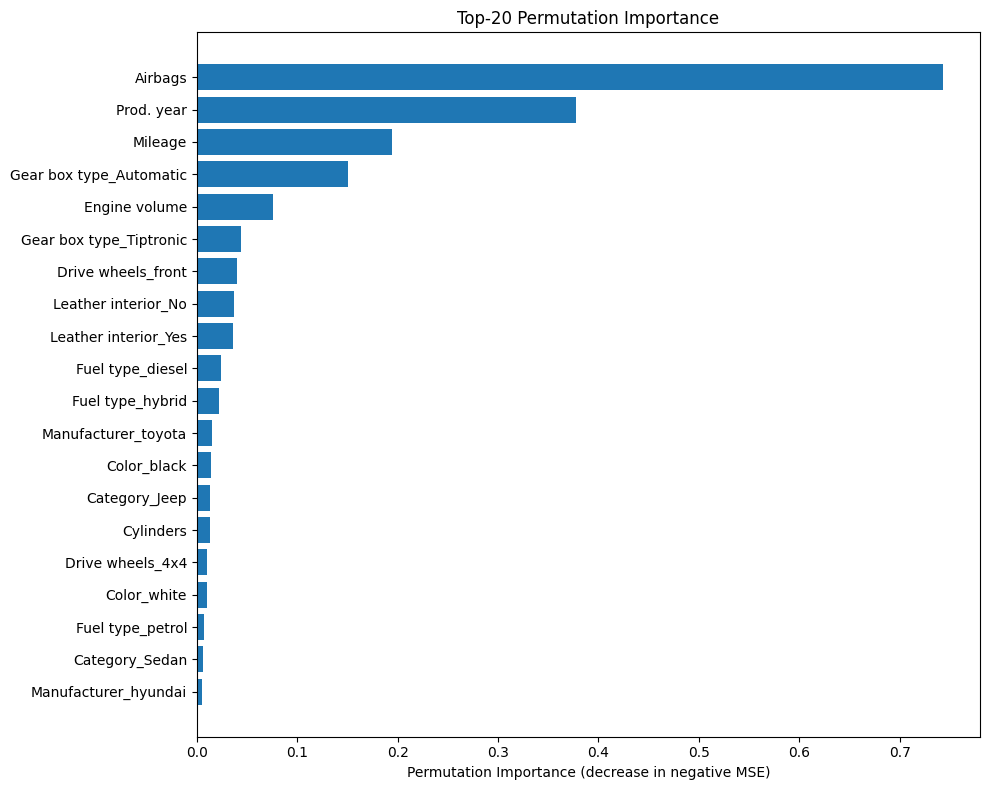

In [9]:
# Имена признаков после one-hot
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = np.concatenate([num_features, cat_feature_names])

from sklearn.inspection import permutation_importance
# Permutation Importance
perm = permutation_importance(
    best_model, X_test_processed, y_test,
    n_repeats=5, random_state=RANDOM_STATE,
    scoring="neg_mean_squared_error", n_jobs=-1
)
perm_imp = perm.importances_mean
perm_idx = np.argsort(perm_imp)[::-1][:20]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.barh(range(20), perm_imp[perm_idx][::-1])
plt.yticks(range(20), [all_feature_names[i] for i in perm_idx][::-1])
plt.xlabel("Permutation Importance (decrease in negative MSE)")
plt.title("Top-20 Permutation Importance")
plt.tight_layout()
plt.savefig(artifacts_path / "rf_importance_permutation.png")
plt.show()

График показывает, что модель разумно использует признаки, но часть из них (Cylinders, цвет, кузов, производитель) можно попробовать удалить. Высокая важность Airbag, что на самом деле удивительно.

Далее попробуем проверить точность модели без параметров: количество цилиндровв двигателе, цвет и количество дверей.

In [10]:
# Убираем Cylinders из числовых, Doors и Color из категориальных
num_features_no_cyl = [f for f in num_features if f != 'Cylinders']
cat_features_no_color_doors = [f for f in cat_features if f not in ['Doors', 'Color']]

X_reduced_all = df[num_features_no_cyl + cat_features_no_color_doors]
X_train_red_all, X_test_red_all, y_train_red_all, y_test_red_all = train_test_split(
    X_reduced_all, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor_red_all = ColumnTransformer([
    ('num', StandardScaler(), num_features_no_cyl),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_no_color_doors)
])
preprocessor_red_all.fit(X_train_red_all)
X_train_red_all = preprocessor_red_all.transform(X_train_red_all)
X_test_red_all = preprocessor_red_all.transform(X_test_red_all)

rf_red_all = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
rf_red_all.fit(X_train_red_all, y_train_red_all)
y_pred_red_all = rf_red_all.predict(X_test_red_all)
metrics_red_all = compute_metrics(y_test_red_all, y_pred_red_all)
metrics_red_all["model"] = "RandomForest_No_Cyl_Color_Doors"
results.append(metrics_red_all)
print_metrics(y_test_red_all, y_pred_red_all, title="Без Cylinders, Color, Doors")


Без Cylinders, Color, Doors
MAE  = 0.2628
MSE  = 0.2103
RMSE = 0.4585


Результаты немного ухутшились, попробуем убрать только параметр количества дверейЮ так как его вообще небыло видно в топ-20 параметрах.

In [11]:
# Удаляем только Doors из категориальных
cat_features_no_doors = [f for f in cat_features if f != 'Doors']
X_no_doors = df[num_features + cat_features_no_doors]
X_train_no_doors, X_test_no_doors, y_train_no_doors, y_test_no_doors = train_test_split(
    X_no_doors, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor_no_doors = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features_no_doors)
])
preprocessor_no_doors.fit(X_train_no_doors)
X_train_no_doors = preprocessor_no_doors.transform(X_train_no_doors)
X_test_no_doors = preprocessor_no_doors.transform(X_test_no_doors)

rf_no_doors = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
rf_no_doors.fit(X_train_no_doors, y_train_no_doors)
y_pred_no_doors = rf_no_doors.predict(X_test_no_doors)
metrics_no_doors = compute_metrics(y_test_no_doors, y_pred_no_doors)
metrics_no_doors["model"] = "RandomForest_No_Doors"
results.append(metrics_no_doors)
print_metrics(y_test_no_doors, y_pred_no_doors, title="Только без Doors")


Только без Doors
MAE  = 0.2600
MSE  = 0.2027
RMSE = 0.4502


К сожадению результаты не улучшились

In [12]:
# Выведем итоговую лучшую модель и сохраним результаты
df_results = pd.DataFrame(results)
# Убедимся, что все модели с уникальными именами, сортируем по RMSE
df_sorted = df_results.sort_values("rmse", ascending=True).reset_index(drop=True)

print("\n=== Итоговое сравнение всех моделей===")
print(df_sorted[["model", "mae", "rmse"]].to_string(index=False))


save_json(df_sorted.to_dict(orient="records"), artifacts_path / "metrics_test_tune.json")
save_json(search_summaries, artifacts_path / "search_summaries_tuned.json")

# Определяем новую лучшую модель
best_row = df_sorted.iloc[0]
best_label = best_row["model"]

print(f"ЛУЧШАЯ МОДЕЛЬ: {best_label}")
print(f"RMSE = {best_row['rmse']:.4f}")
print(f"MAE  = {best_row['mae']:.4f}")

meta = {
    "best_model_label": best_label,
    "test_metrics": best_row.to_dict(),
    "search_summary": search_summaries.get(best_label, None),
    "random_state": RANDOM_STATE,
    "target": "log_price"
}
save_json(meta, configs_path / "best_model_meta.json")


=== Итоговое сравнение всех моделей===
                          model      mae     rmse
             RandomForest_Tuned 0.259294 0.449581
          RandomForest_No_Doors 0.259969 0.450213
          RandomForest_No_Doors 0.259969 0.450213
RandomForest_No_Cyl_Color_Doors 0.262824 0.458545
RandomForest_No_Cyl_Color_Doors 0.262824 0.458545
          RandomForest_best_old 0.265759 0.461271
ЛУЧШАЯ МОДЕЛЬ: RandomForest_Tuned
RMSE = 0.4496
MAE  = 0.2593
